In [7]:
import matplotlib.pyplot as plt
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
import scienceplots
import lovelyplots
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.isa import expected_costs
from gulps.utils.logging_config import logger
from gulps.utils.visualize import render_path
import itertools

In [19]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


full_isa = [
    (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "1"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "2"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "3"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 4), 1 / 4, "4"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 5), 1 / 5, "5"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 6), 1 / 6, "6"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 7), 1 / 7, "7"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 8), 1 / 8, "8"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 9), 1 / 9, "9"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 10), 1 / 10, "10"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 11), 1 / 11, "11"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 12), 1 / 12, "12"),
]
gate_set, costs, names = zip(*full_isa)
decomposer = GulpsDecomposer(
    gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
)
u_gi = GateInvariants.from_unitary(iSwapGate())

In [9]:
results = []  # (used_gate_count, cost, label)

# instead of creating separate decomposers, enumerate manually.
# this should be much faster, skips recomputing identical sentences.
for sentence in tqdm(decomposer.isa.enumerate()):
    # heuristic filter to skip a full LP for obvious non-starters
    if sum(gate.strength for gate in sentence) < u_gi.strength:
        continue

    sentence_out = decomposer._try_lp(sentence, u_gi)[0]

    if sentence_out is None:
        continue

    # save it in results
    # Actual number of unique gates used in the decomposition
    used_gate_count = len(set(sentence_out))
    names = [g.name for g in sentence_out]

    # Compute cost
    iswap_cost = sum(decomposer.isa.cost_dict[g] for g in sentence_out)

    # Label with denominators only
    label = "{" + ",".join(names) + "}"
    results.append((used_gate_count, float(iswap_cost), label))

    # if sentence_out is [fsim, fsim, fsim]:
    if iswap_cost == 1.5:
        break

# Sort by used-gate count then cost
results.sort(key=lambda r: (r[0], r[1]))

0it [00:00, ?it/s]

2732it [00:06, 419.83it/s]


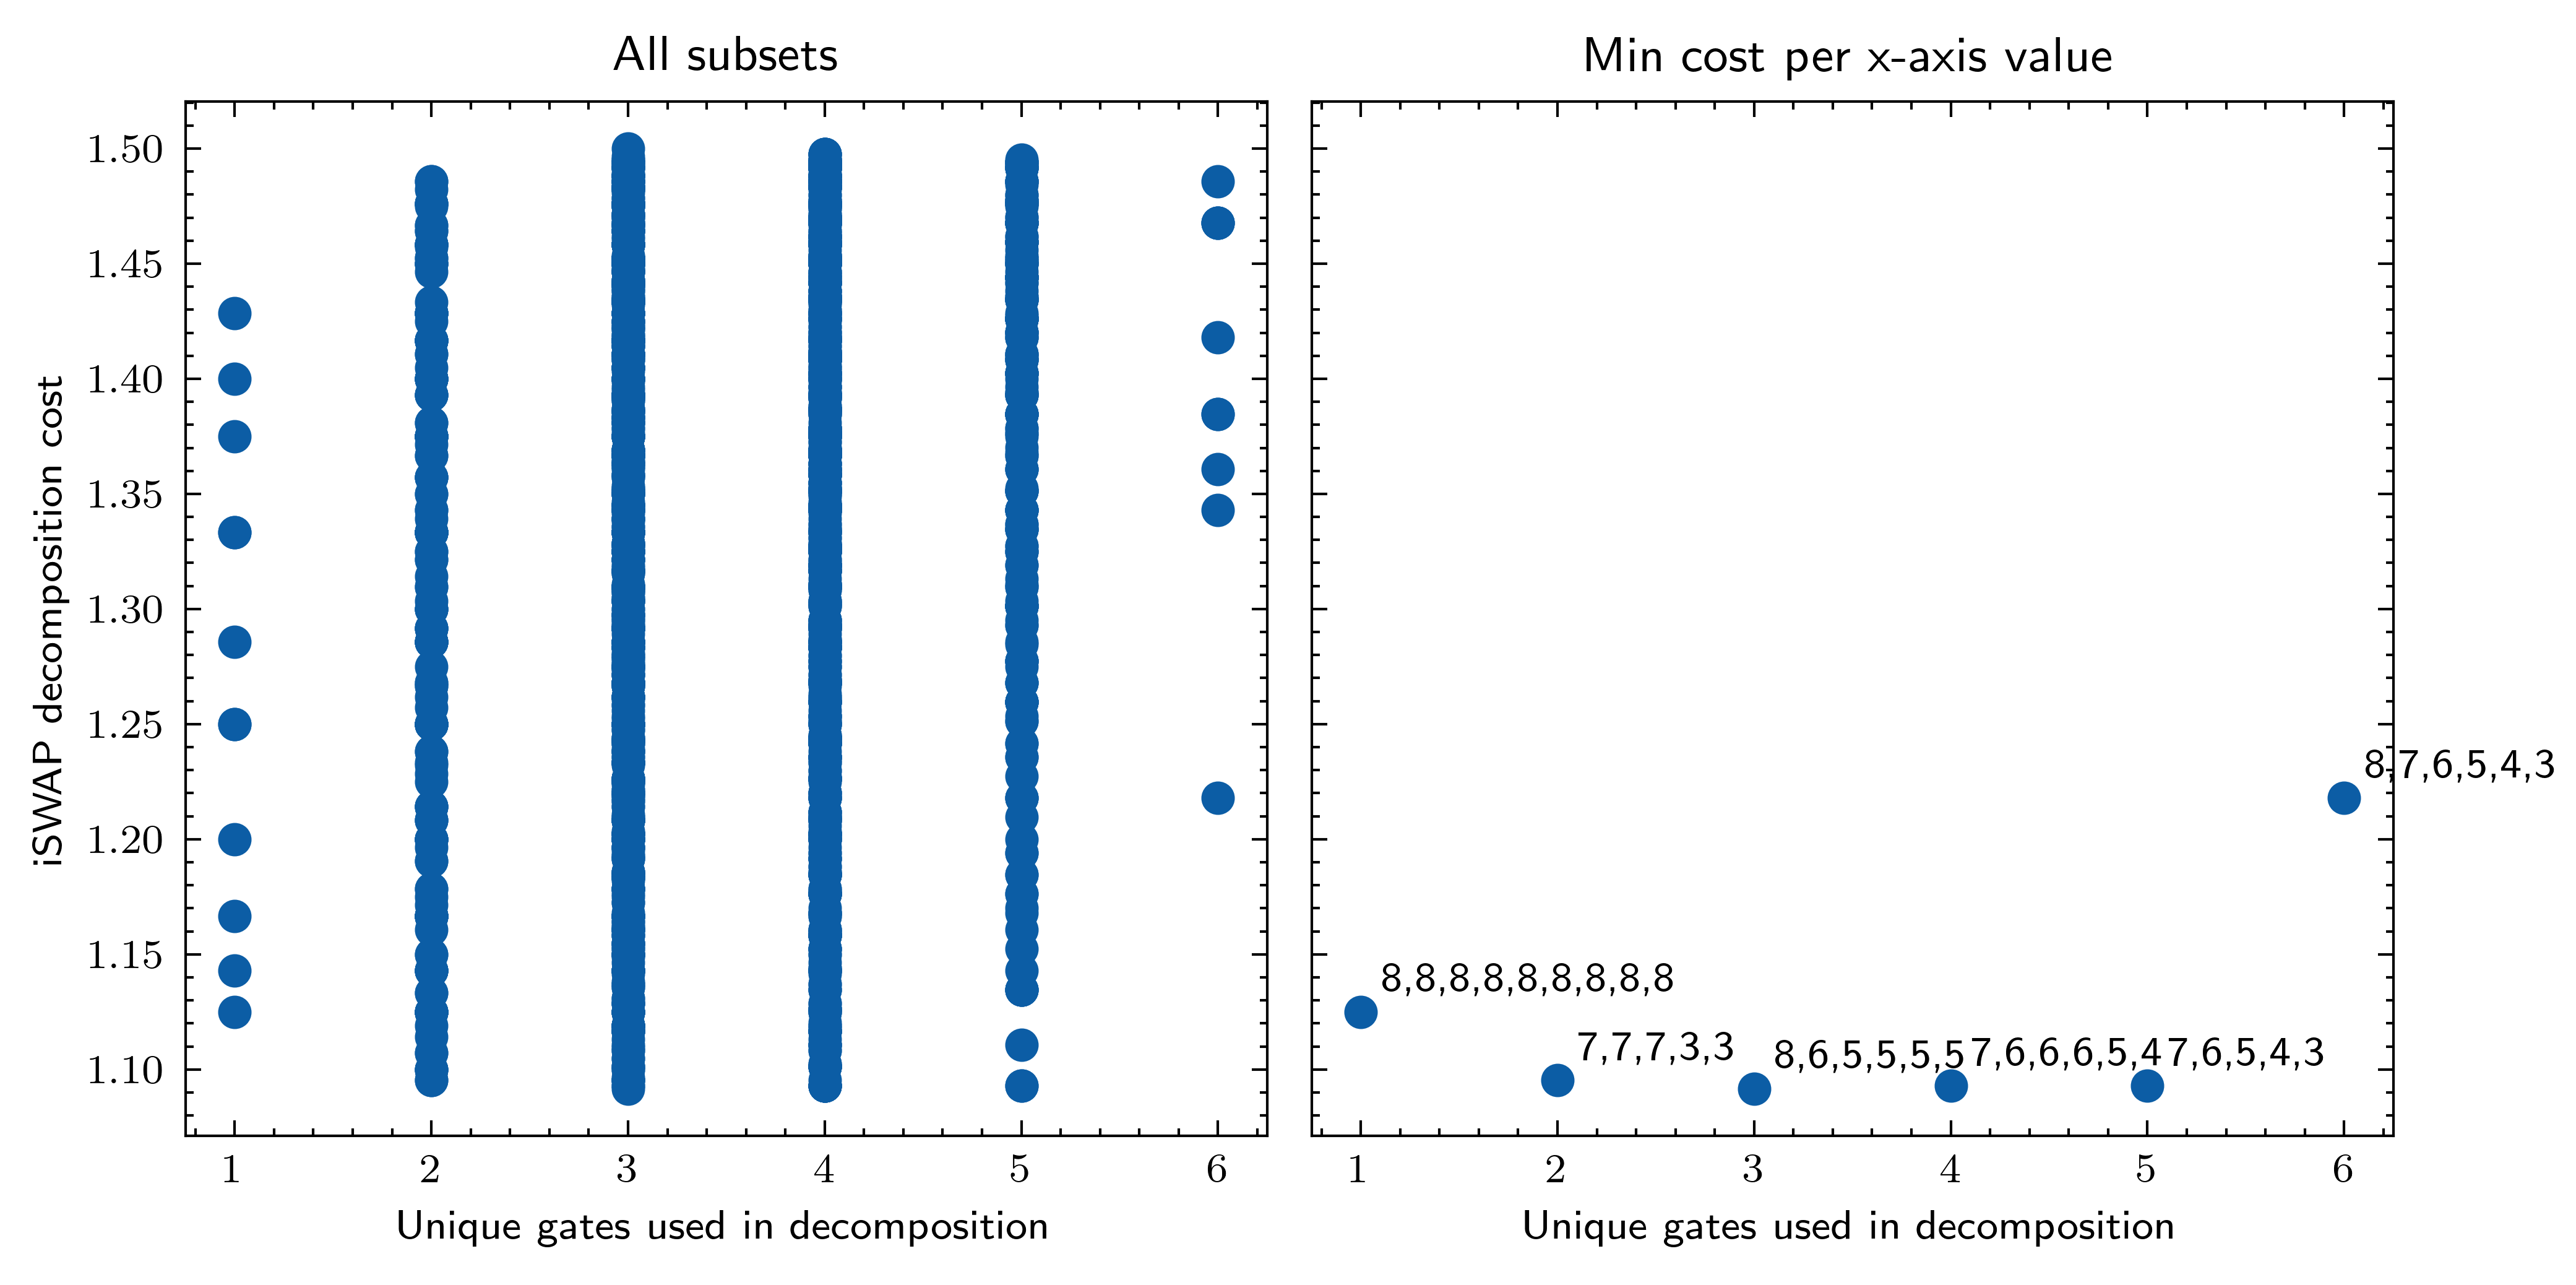

In [10]:
from collections import defaultdict

xs_all = [count for count, _, _ in results]  # jitter
ys_all = [cost for _, cost, _ in results]

# Group results by used_gate_count, keep only min-cost entry
best_by_count = {}
for count, cost, label in results:
    if count not in best_by_count or cost < best_by_count[count][0]:
        best_by_count[count] = (cost, label)

# Sort by x-axis value
best_items = sorted(best_by_count.items())

# Extract for plotting
xs_min = [count for count, _ in best_items]
ys_min = [cost for _, (cost, _) in best_items]
labels_min = [label for _, (_, label) in best_items]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True)

    # --- Left: all results ---
    axs[0].scatter(xs_all, ys_all, s=30)
    axs[0].set_xlabel("Unique gates used in decomposition")
    axs[0].set_ylabel("iSWAP decomposition cost")
    axs[0].set_title("All subsets")

    # --- Right: min-cost per used_gate_count ---
    axs[1].scatter(xs_min, ys_min, s=30)
    axs[1].set_xlabel("Unique gates used in decomposition")
    axs[1].set_title("Min cost per x-axis value")
    for x, y, label in zip(xs_min, ys_min, labels_min):
        axs[1].annotate(
            label, (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8
        )

    fig.tight_layout()

plt.show()


____

In [24]:
u_gi_cnot = GateInvariants.from_unitary(CXGate())

In [31]:
GateInvariants.from_unitary(CXGate().power(1 / 4)).monodromy

(np.float64(0.06250000000000008),
 np.float64(0.06250000000000006),
 np.float64(-0.06250000000000006))

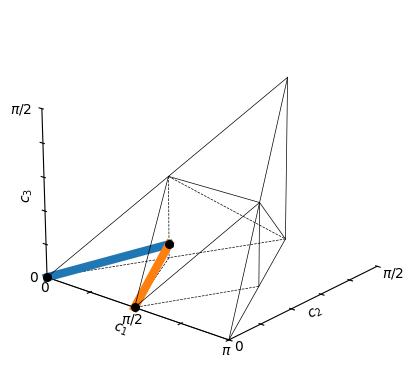

In [26]:
sentence_out, intermediates_out = decomposer._best_decomposition(target_inv=u_gi_cnot)
ax = render_path(intermediates_out)
plt.show();

In [ ]:
# want combinatoric sweep over fractional fsim gates between fsim^1 and fsim^(1/6)
u_gi = GateInvariants.from_unitary(iSwapGate())
sentence_out = decomposer._best_decomposition(u_gi)[0]
iswap_cost = sum(decomposer.isa.cost_dict[g] for g in sentence_out)
iswap_cost

1.0916666666666668

In [ ]:
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_costs(decomposer.isa.coverage_set))

[gulps.gulps_decomposer] DEBUG: Sentence: ['8', '6', '5', '5', '5', '5']
[gulps.gulps_decomposer] DEBUG: Intermediates: [(np.float64(0.05729166666666646), np.float64(0.005208333333333332), np.float64(0.005208333333333332), np.float64(-0.06770833333333312)), (np.float64(0.1333333333333333), np.float64(0.012152777777777778), np.float64(-0.008333333333333328), np.float64(-0.13715277777777776)), (np.float64(0.22499999999999998), np.float64(0.0), np.float64(-0.008333333333333328), np.float64(-0.21666666666666665)), (np.float64(0.31666666666666665), np.float64(0.0), np.float64(-0.016666666666666656), np.float64(-0.3)), (np.float64(0.4083333333333333), np.float64(-0.008333333333333328), np.float64(-0.008333333333333328), np.float64(-0.3916666666666667)), (np.float64(0.5), np.float64(0.0), np.float64(0.0), np.float64(-0.5))]
[gulps.local_numerics] DEBUG: => Success on [HARD 1] (componentwise |residual| ≤ 5.0e-09)
[gulps.local_numerics] DEBUG: ✅ LM synthesis SUCCESS on HARD attempt 1 (residual=

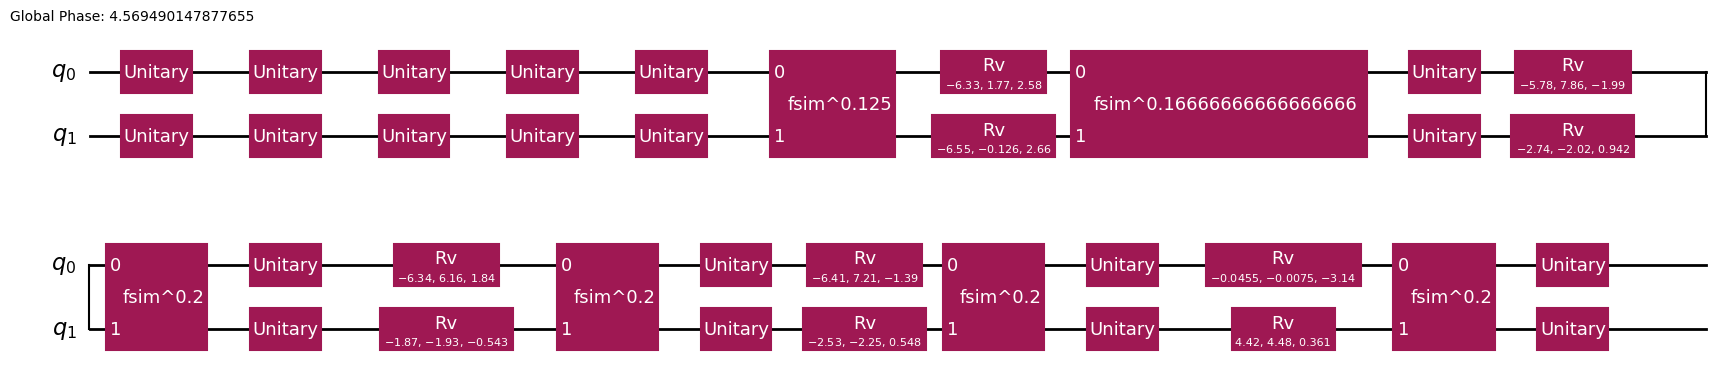

In [ ]:
u = iSwapGate()
output_qc = decomposer(u)
v = Operator(output_qc)
fid = average_gate_fidelity(u, v)
output_qc.draw("mpl")